## **Segundo Proyecto: Algoritmos de Búsqueda** 
**Curso:** Inteligencia Artificial - CC3085  



**Descripción General:**
En este proyecto se implementan y comparan diferentes algoritmos de búsqueda para resolver laberintos generados de forma aleatoria. Se estudian tanto algoritmos de generación de laberintos como técnicas de búsqueda clásicas en inteligencia artificial.

El objetivo principal es analizar el desempeño de algoritmos como BFS, DFS, Dijkstra y A*, evaluando métricas como:

- Nodos explorados
- Longitud del camino encontrado
- Tiempo de ejecución

Además, se generan múltiples escenarios experimentales para obtener conclusiones fundamentadas sobre cuál algoritmo es más eficiente en distintos contextos.

---

### ***Configuración Base***

Se importan las librerías necesarias y se define el grid $M \times N$, estructuras auxiliares para representar el laberinto y sus vecinos, y las constantes globales del proyecto.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import random
import time
import heapq
import pandas as pd
from collections import deque
from IPython.display import clear_output

#### ***Constantes Globales***

Para evitar inconsistencias entre implementaciones, todos los parámetros del proyecto se centralizan aquí.

**Parámetros**

- Tamaños de grid (según el PDF):
  - Demo Problema 1: $31 \times 41$
  - Problema 2 (prueba): $60 \times 80$ → se usa $61 \times 81$ para garantizar dimensiones impares
  - Problema 3 (benchmark): $45 \times 55$

- Número de simulaciones: $K = 25$

- Punto inicial: $(1,1)$  
- Punto final: $(\text{filas}-2, \text{columnas}-2)$

- Heurística A*: Distancia Manhattan

In [ ]:
# Tamaños de grid por problema 
FILAS_P1, COLS_P1 = 31, 41   # Demo generación
FILAS_P2, COLS_P2 = 61, 81   # Problema 2: 60x80 → impar
FILAS_P3, COLS_P3 = 45, 55   # Benchmark

K_SIMULACIONES = 25

# Colores para visualizaciones 
COLOR_PARED    = 0
COLOR_CAMINO   = 1
COLOR_VISITADO = 2
COLOR_RUTA     = 3
COLOR_INICIO   = 4
COLOR_FIN      = 5

CMAP_LABERINTO = mcolors.ListedColormap(['black', 'white', '#90CAF9', '#FFD600', '#00E676', '#FF1744'])
# 0=pared  1=camino  2=explorado  3=ruta  4=inicio  5=fin

def dibujar_laberinto(laberinto, titulo="Generando Laberinto...", pausa=0.05):
    clear_output(wait=True)
    plt.figure(figsize=(10, 6))
    plt.imshow(laberinto, cmap='binary')
    plt.title(titulo, fontsize=13)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()
    time.sleep(pausa)

### ***Generación de Laberintos***

Se implementan dos algoritmos con estructuras contrastantes para analizar su impacto en los algoritmos de búsqueda.

***Algoritmo de Prim***

Genera un laberinto haciendo crecer un Árbol de Expansión Mínima (MST) desde un punto inicial aleatorio. En cada paso, elige aleatoriamente una pared que separa una celda visitada de una no visitada y la elimina.

**Características:**
- Estructura orgánica, con crecimiento radial
- Muchos callejones sin salida y alta ramificación
- El camino solución suele ser tortuoso

**Impacto en búsqueda:**
Fuerza a BFS y DFS a explorar una gran cantidad de nodos antes de encontrar la salida.

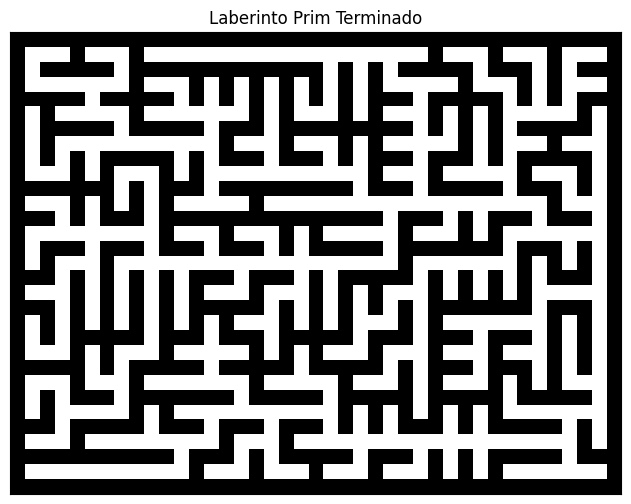

***División Recursiva***

Divide el espacio agregando muros de forma recursiva.

**Características:**
- Pasillos largos y rectos
- Estructura tipo "bloques"

**Impacto:**
Favorece algoritmos heurísticos como A*.

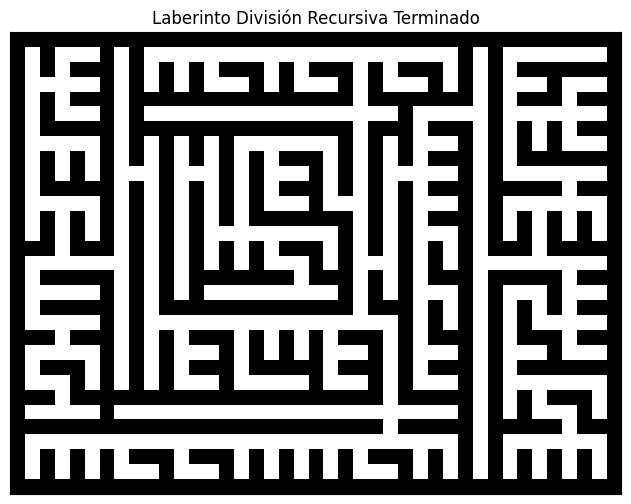

### ***Algoritmos de Búsqueda***

Se busca la ruta entre dos puntos del laberinto.

**Algoritmos**
- BFS: óptimo en grafos no ponderados, pero explora mucho
- DFS: rápido en algunos casos, no garantiza optimalidad
- Dijkstra: garantiza mejor camino con mayor costo computacional
- A*: usa heurística (Manhattan), balance entre eficiencia y optimalidad

**Objetivo**

Analizar:
- Nodos explorados
- Longitud del camino
- Tiempo de ejecución

### ***Comparación de Algoritmos***

Se evalúan los algoritmos en múltiples escenarios aleatorios.

***Benchmark***

Se generan $K=25$ laberintos de tamaño $45 \times 55$.

Para cada uno:
- Ejecutar BFS, DFS, Dijkstra y A*
- Medir:
  - Nodos explorados
  - Tiempo de ejecución
  - Longitud del camino

***Tablas***

Se construye una tabla con:
- Algoritmo
- Nodos explorados
- Tiempo
- Longitud del camino

Se calcula ranking por escenario y promedio general.

***Gráficas***

Se generan visualizaciones con matplotlib:

- Comparación de tiempos
- Comparación de nodos explorados
- Ranking promedio

Objetivo: identificar tendencias de desempeño.

### ***Conclusiones***
- ¿Qué algoritmo fue más rápido en promedio?
- ¿Cuál exploró menos nodos?
- ¿Cuál encontró mejores rutas?
- ¿Cómo afecta la estructura del laberinto (Prim vs División Recursiva)?
- ¿En qué casos falla DFS?
- ¿Cuándo A* supera claramente a los demás?